# ML pipeline for UNO

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision.io import decode_image
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader

from ML_utils import *
from image_utils import *

First let us define some useful global variables :
- File paths to the data
- Translations from text to vector representation
- ML hyperparameters

In [2]:
# Filenames to access data
img_dir = os.path.join("iapr-26-uno-vision-challenge", "train_images")
annotations_file = os.path.join("iapr-26-uno-vision-challenge", "train") + '.csv'
checkpoint_dir = "checkpoints"
checkpoint_model_name = "model_test2"
if (not os.path.exists(checkpoint_dir)):
    os.mkdir(checkpoint_dir)
checkpoint_path = os.path.join(checkpoint_dir, checkpoint_model_name) + '.pt'

# List of cards : digits (0 to 9) with color, specials (draw_2, reverse, skip) with color, other special (draw_4, wild)
card_name_list = [str(color) + '_' + str(digit) for digit in range(10) for color in ['r', 'g', 'b', 'y']]
card_name_list += [str(color) + '_' + str(special) for special in ['draw_2', 'reverse', 'skip'] for color in ['r', 'g', 'b', 'y']]
card_name_list += ['draw_4', 'wild']
# Mapping from card name to its index in vector form
card_name_to_index = {card_name : index for index, card_name in enumerate(card_name_list)}

# General ML parameters :
torch.manual_seed(0)
generator = torch.Generator().manual_seed(42)
train_val_test_split = [0.7, 0.15, 0.15]
learning_rate = 0.001
batch_size = 32 # True batch size (number of samples per gradient descent updates)
batch_size_simul = 4 # Number of samples loaded simultaneously (to minimize memory consumption)
nb_epochs = 50
p_dropout = 0.0

RGB_normalization_mean = torch.tensor([0.485, 0.456, 0.406])
RGB_normalization_std = torch.tensor([0.229, 0.224, 0.225])
transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=RGB_normalization_mean, std=RGB_normalization_std),
])

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")

Using device cpu


Then let us define helper functions to handle transformations between data and ML model.

In [4]:
def output_transform(model_output):
    return model_output.softmax(dim=1)

def label_string_to_tensor(label):
    # Give the model representation from the label annotation :
    output = torch.zeros(len(card_name_list) + 1)
    if (label == 'EMPTY'):
        output[-1] = 1
    else:
        for card_name in label.split(";"):
            output[card_name_to_index[card_name]] += 1
    output = output / torch.sum(output)
    return output

def label_tensor_to_string(vector):
    # Give the label annotation from the model representation :
    card_name_list_completed = card_name_list + ['EMPTY']
    card_list = []
    # Go from probabilities to number of cards
    vector_list = list((1.49 * vector / torch.max(vector)).flatten())
    for index, value in enumerate(vector_list):
        nb_cards = round(value.item())
        while (nb_cards > 0):
            card_list.append(card_name_list_completed[index])
            nb_cards -= 1
    output = ';'.join(card_list)
    return output

def image_reverse_RGB_normalization(img):
    RGB_std = RGB_normalization_std.reshape((3,1,1)).to(img.device)
    RGB_mean = RGB_normalization_mean.reshape((3,1,1)).to(img.device)
    return (255*(img * RGB_std + RGB_mean)).to(torch.uint8)

Image shape torch.Size([3, 2662, 4000])
Divided image shape torch.Size([3, 886, 2228])


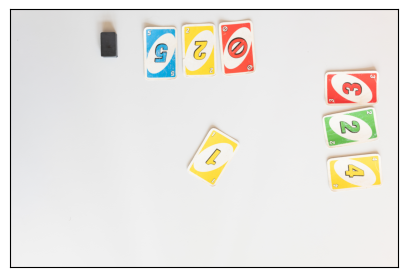

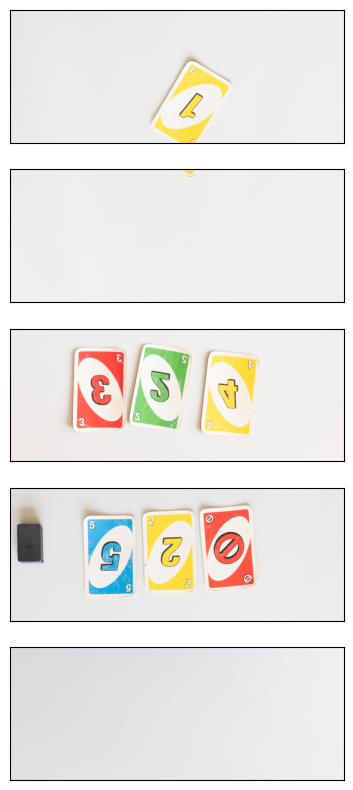

In [5]:
# Take a look a the image in the dataset
full_image_example = decode_image(os.path.join(img_dir, 'L1000770.jpg'))
print(f"Image shape {full_image_example.shape}")
divided_images_example = [divide_image(full_image_example, i) for i in range(5)]
print(f"Divided image shape {divided_images_example[0].shape}")

display_tensor_images(full_image_example)
display_tensor_images(divided_images_example, transform=None, shape=(1, len(divided_images_example)), figsize=(5,10))

In [6]:
class UNOImageDataset(Dataset):
    def __init__(self, img_dir, annotations_file, divide_image, label_string_to_tensor, transform=None, device='cpu'):
        # Annotations contains : 'image_id', 'center_card', 'active_player', 'player_1_cards', 'player_2_cards', 'player_3_cards', 'player_4_cards'
        annotations = pd.read_csv(annotations_file)
        self.device = device
        self.transform = transform
        # Store image labels
        self.img_labels = torch.zeros((5*len(annotations['image_id']), len(card_name_list) + 1), dtype=torch.float32)
        self.img_labels[0::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['center_card']])
        self.img_labels[1::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['player_1_cards']])
        self.img_labels[2::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['player_2_cards']])
        self.img_labels[3::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['player_3_cards']])
        self.img_labels[4::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['player_4_cards']])
        # Store images
        self.imgs = torch.zeros((5*len(annotations['image_id']), 3, 886, 2228), dtype=torch.uint8)
        for img_index in range(len(annotations['image_id'])):
            img_path = os.path.join(img_dir, annotations['image_id'][img_index]) + '.jpg'
            full_image = decode_image(img_path)
            for divided_img_index in range(5):
                self.imgs[img_index*5 + divided_img_index] = divide_image(full_image, divided_img_index)

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        image = self.imgs[idx]
        if (self.transform != None):
            image = self.transform(image)
        image = image.to(self.device)
        label = self.img_labels[idx].to(self.device)
        return image, label

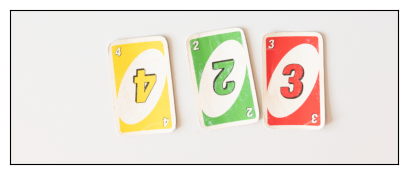

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.3333, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000])
g_2;r_3;y_4


In [7]:
full_dataset = UNOImageDataset(img_dir, annotations_file, divide_image, label_string_to_tensor, transform=transforms, device=device)
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(full_dataset, train_val_test_split, generator=generator)

# Display sample
image_sample, label_sample = full_dataset.__getitem__(2)
with torch.no_grad():
    display_tensor_images(image_sample, transform=image_reverse_RGB_normalization)
    print(label_sample)
    print(label_tensor_to_string(label_sample))

## Define the model

In [8]:
def conv2d_resblock(nb_channels, kernel_size, p_dropout, padding_mode='reflect'):
    padding = kernel_size//2
    layers_list = [nn.Conv2d(in_channels=nb_channels, out_channels=nb_channels, kernel_size=kernel_size, 
                             padding=kernel_size//2, padding_mode=padding_mode), 
                   nn.BatchNorm2d(nb_channels), 
                   nn.ReLU(inplace=True), 
                   nn.Conv2d(in_channels=nb_channels, out_channels=nb_channels, kernel_size=kernel_size, 
                             padding=kernel_size//2, padding_mode=padding_mode), 
                   nn.BatchNorm2d(nb_channels), 
                   nn.ReLU(inplace=True), 
                   nn.Dropout(p_dropout)]
    return nn.Sequential(*layers_list)

class UNO_Model(nn.Module):
    def __init__(self):
        super().__init__()
        # Recall shape 3, 886, 2228
        self.conv1 = nn.Sequential(nn.Conv2d(3, 6, 7, stride=2), nn.BatchNorm2d(6), nn.ReLU(inplace=True))
        self.resBlock1_1 = conv2d_resblock(6, 3, p_dropout)
        self.resBlock1_2 = conv2d_resblock(6, 3, p_dropout)
        self.resBlock1_3 = conv2d_resblock(6, 3, p_dropout)
        self.resBlock1_4 = conv2d_resblock(6, 3, p_dropout)
        self.conv2 = nn.Sequential(nn.Conv2d(6, 16, 3, stride=2), nn.BatchNorm2d(16), nn.ReLU(inplace=True))
        self.resBlock2_1 = conv2d_resblock(16, 3, p_dropout)
        self.resBlock2_2 = conv2d_resblock(16, 3, p_dropout)
        self.resBlock2_3 = conv2d_resblock(16, 3, p_dropout)
        self.resBlock2_4 = conv2d_resblock(16, 3, p_dropout)
        self.conv3 = nn.Sequential(nn.Conv2d(16, 32, 3, stride=2), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.resBlock3_1 = conv2d_resblock(32, 3, p_dropout)
        self.resBlock3_2 = conv2d_resblock(32, 3, p_dropout)
        self.resBlock3_3 = conv2d_resblock(32, 3, p_dropout)
        self.resBlock3_4 = conv2d_resblock(32, 3, p_dropout)
        self.conv4 = nn.Sequential(nn.Conv2d(32, 64, 3, stride=2), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.resBlock4_1 = conv2d_resblock(64, 3, p_dropout)
        self.resBlock4_2 = conv2d_resblock(64, 3, p_dropout)
        self.resBlock4_3 = conv2d_resblock(64, 3, p_dropout)
        self.resBlock4_4 = conv2d_resblock(64, 3, p_dropout)
        self.conv5 = nn.Sequential(nn.Conv2d(64, 128, 3, stride=2), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.resBlock5_1 = conv2d_resblock(128, 3, p_dropout)
        self.resBlock5_2 = conv2d_resblock(128, 3, p_dropout)
        self.resBlock5_3 = conv2d_resblock(128, 3, p_dropout)
        self.resBlock5_4 = conv2d_resblock(128, 3, p_dropout)
        
        self.avgPooling = nn.AvgPool2d((26, 68))
        
        self.classifier = nn.Sequential(
            nn.Linear(128, 256), 
            nn.ReLU(inplace=True), 
            nn.Linear(256, 128), 
            nn.ReLU(inplace=True), 
            nn.Linear(128, 55), 
        )

    def forward(self, x):
        x = self.conv1(x)
        x = x + self.resBlock1_1(x)
        x = x + self.resBlock1_2(x)
        x = x + self.resBlock1_3(x)
        x = x + self.resBlock1_4(x)
        x = self.conv2(x)
        x = x + self.resBlock2_1(x)
        x = x + self.resBlock2_2(x)
        x = x + self.resBlock2_3(x)
        x = x + self.resBlock2_4(x)
        x = self.conv3(x)
        x = x + self.resBlock3_1(x)
        x = x + self.resBlock3_2(x)
        x = x + self.resBlock3_3(x)
        x = x + self.resBlock3_4(x)
        x = self.conv4(x)
        x = x + self.resBlock4_1(x)
        x = x + self.resBlock4_2(x)
        x = x + self.resBlock4_3(x)
        x = x + self.resBlock4_4(x)
        x = self.conv5(x)
        x = x + self.resBlock5_1(x)
        x = x + self.resBlock5_2(x)
        x = x + self.resBlock5_3(x)
        x = x + self.resBlock5_4(x)
        x = self.avgPooling(x)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = self.classifier(x)
        return x

model = UNO_Model()
torch.manual_seed(0)
model.apply(init_weights)
model = model.to(device)
print(model)
print(f"Number of parameters : {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

UNO_Model(
  (conv1): Sequential(
    (0): Conv2d(3, 6, kernel_size=(7, 7), stride=(2, 2))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (resBlock1_1): Sequential(
    (0): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (4): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Dropout(p=0.0, inplace=False)
  )
  (resBlock1_2): Sequential(
    (0): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1)

In [9]:
with torch.no_grad():
    print(output_transform(model(image_sample.unsqueeze(0))))
    print(label_sample)

tensor([[0.0164, 0.0091, 0.0333, 0.0109, 0.0092, 0.0148, 0.0083, 0.0175, 0.0123,
         0.0095, 0.0124, 0.0127, 0.0117, 0.0079, 0.0248, 0.0254, 0.0230, 0.0222,
         0.0309, 0.0215, 0.0104, 0.0153, 0.0379, 0.0139, 0.0175, 0.0214, 0.0116,
         0.0089, 0.0202, 0.0286, 0.0144, 0.0243, 0.0186, 0.0171, 0.0266, 0.0309,
         0.0119, 0.0308, 0.0193, 0.0171, 0.0165, 0.0105, 0.0229, 0.0255, 0.0113,
         0.0139, 0.0160, 0.0166, 0.0251, 0.0159, 0.0187, 0.0219, 0.0129, 0.0226,
         0.0192]])
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.3333, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000]

## Train the model

In [10]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, nb_epochs)

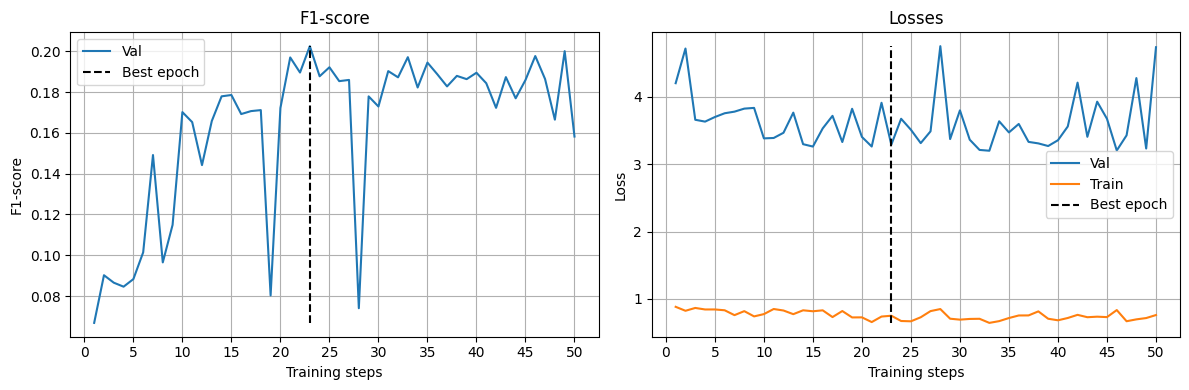

100%|███████████████████████████████████████████████████████████████████████████████| 50/50 [4:48:21<00:00, 346.03s/it]

Current train loss = 0.7600887694828947, current validation loss = 4.736772631127082, current validation f1 loss = 0.15821687489787123
Best model at epoch 23 -> 20.25% F1 score


In [11]:
train_output = train(model, train_dataset, val_dataset, batch_size, nb_epochs, optimizer, scheduler, loss_fn, 
                     output_transform, checkpoint_path, show_plot=True, batch_size_simul=batch_size_simul, generator=generator)
best_model, best_f1, best_epoch, val_f1s, val_losses, train_losses = train_output
print(f"Best model at epoch {best_epoch} -> {100*best_f1:.2f}% F1 score")

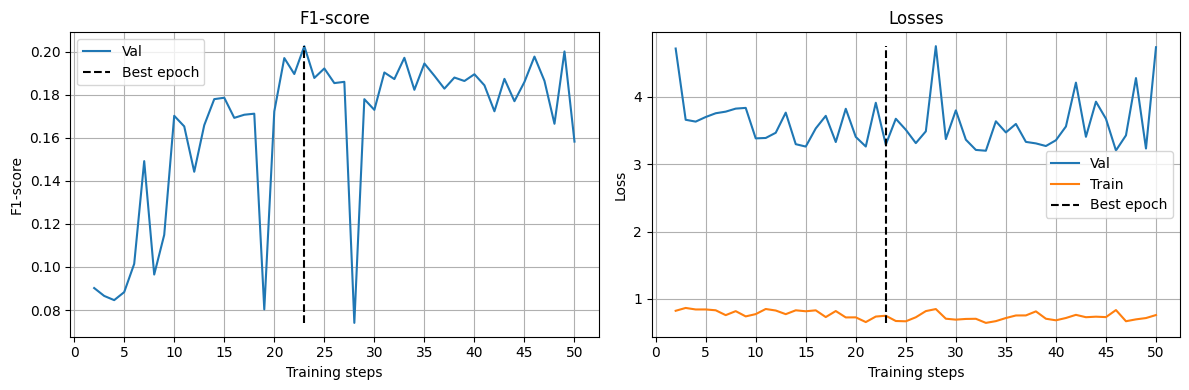

In [12]:
plot_training(best_epoch, val_f1s, val_losses, train_losses, first_epoch_plot=2)

In [13]:
with torch.no_grad():
    model = UNO_Model().to(device)
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    label_predict = output_transform(model(image_sample.unsqueeze(0)))
    print(label_predict)
    print(label_tensor_to_string(label_predict))
    print(label_sample)
    print(label_tensor_to_string(label_sample))

tensor([[0.0267, 0.0096, 0.0145, 0.0266, 0.0154, 0.0151, 0.0241, 0.0055, 0.0108,
         0.0188, 0.0177, 0.0156, 0.0315, 0.0144, 0.0267, 0.0199, 0.0256, 0.0192,
         0.0228, 0.0185, 0.0134, 0.0248, 0.0244, 0.0112, 0.0130, 0.0172, 0.0167,
         0.0101, 0.0157, 0.0196, 0.0113, 0.0430, 0.0159, 0.0210, 0.0120, 0.0261,
         0.0260, 0.0058, 0.0157, 0.0056, 0.0213, 0.0097, 0.0259, 0.0134, 0.0099,
         0.0196, 0.0125, 0.0194, 0.0088, 0.0116, 0.0115, 0.0185, 0.0410, 0.0320,
         0.0172]])
r_0;b_0;y_0;r_1;g_1;b_1;g_2;b_2;y_2;r_3;g_3;b_3;y_3;r_4;g_4;b_4;y_4;g_5;b_5;g_6;b_6;r_7;g_7;y_7;r_8;g_8;y_8;r_9;b_9;r_draw_2;b_draw_2;g_reverse;y_reverse;y_skip;draw_4;wild;EMPTY
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.3333, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.00